# Etapa 3 - Análise de Sazonalidade

Nesta etapa será analisado o comportamento sazonal das variáveis climáticas ao longo do ano. 

Para isso, serão calculadas as médias mensais das variáveis de precipitação, temperatura média e radiação solar. Em seguida, serão gerados gráficos para identificar os meses com maior incidência de radiação solar e, consequentemente, maior potencial para geração fotovoltaica.

Também será aplicada a decomposição da série temporal da radiação solar, permitindo identificar os componentes de tendência, sazonalidade e ruído presentes na série.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Essa biblioteca é usada para decompor séries temporais em seus componentes: tendência, série original, componente sazonal e resíduos.
from statsmodels.tsa.seasonal import seasonal_decompose


#Algo bastante usado para entender padrões periódicos.

In [22]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

In [23]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [24]:
dados = pd.read_excel(file_path, sheet_name="dados")

In [25]:
dados.head()

,Data,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação
0,1984-01-01,0.989776,0.518743,25.419519,211.801254
1,1984-01-02,0.166336,0.587044,26.399133,204.752853
2,1984-01-03,0.256648,0.419522,26.202539,217.430527
3,1984-01-04,0.000000,0.478503,26.720331,222.075912
4,1984-01-05,0.000000,0.374592,27.286249,220.100525


In [26]:
dados["Data"] = pd.to_datetime(dados["Data"])

In [27]:
dados["mes"] = dados["Data"].dt.month

In [28]:
dados.head()

,Data,mm/dia - Precipitação,mm/dia - Evapotranspiração,C° - Temperatura Média,W/m² - Radiação,mes
0,1984-01-01,0.989776,0.518743,25.419519,211.801254,1
1,1984-01-02,0.166336,0.587044,26.399133,204.752853,1
2,1984-01-03,0.256648,0.419522,26.202539,217.430527,1
3,1984-01-04,0.000000,0.478503,26.720331,222.075912,1
4,1984-01-05,0.000000,0.374592,27.286249,220.100525,1


In [29]:
dados_mensais = dados.groupby("mes").mean(numeric_only=True)

# aqui eu fiz a média de todos os janeiros, todos os fevereiros, todos os marços etc.

In [30]:
dados_mensais.columns.tolist()

['mm/dia - Precipitação',
 'mm/dia - Evapotranspiração ',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [31]:
dados_mensais.columns = dados_mensais.columns.str.strip()

In [32]:
dados_mensais.columns.tolist()

['mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

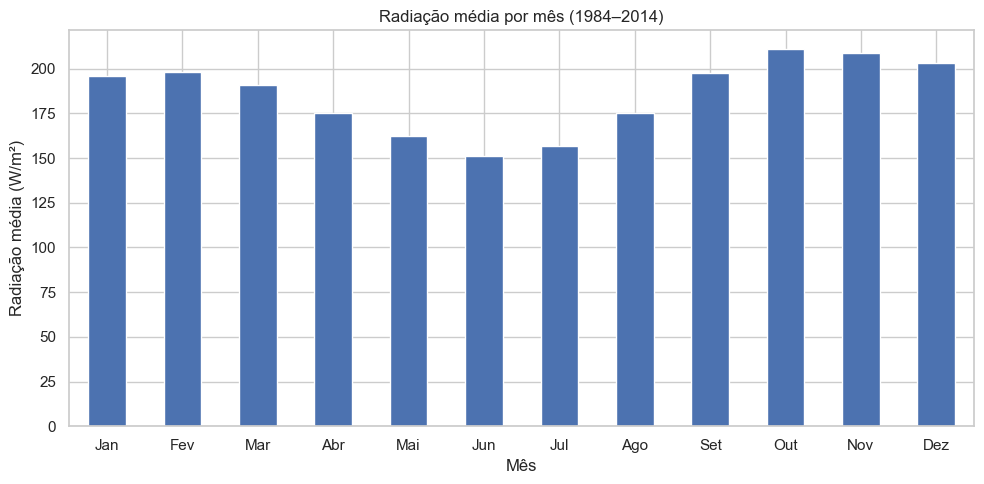

In [33]:
meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

ax = dados_mensais["W/m² - Radiação"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Radiação média por mês (1984–2014)",
)

ax.set_xticklabels(meses, rotation=0)
plt.xlabel("Mês")
plt.ylabel("Radiação média (W/m²)")
plt.tight_layout()
plt.show()

### 3.1 Radiação média por mês
Pelo gráfico e pelos valores observados:

- **maior radiação:** mês 10
- **valor médio:** ≈ **210,90 W/m²**
- **menor radiação:** mês 6
- **valor médio:** ≈ **150,99 W/m²**
### O que isso indica
A radiação solar não permanece constante ao longo do ano. Os dados mostram um comportamento sazonal bem definido, caracterizado por:

- redução gradual até o meio do ano;
- aumento a partir do segundo semestre;
- pico de radiação em outubro.
### Interpretação climática
Esse resultado indica que o **potencial fotovoltaico da região é maior no segundo semestre**, principalmente entre:

- setembro;
- outubro;
- novembro;
- dezembro.

Já os menores valores ocorrem próximos de:

- junho;
- julho.

Assim, para o objetivo de identificar os meses com maior radiação e menor potencial fotovoltaico, a análise mostra que:

- **maior potencial fotovoltaico:** outubro;
- **menor potencial fotovoltaico:** junho.

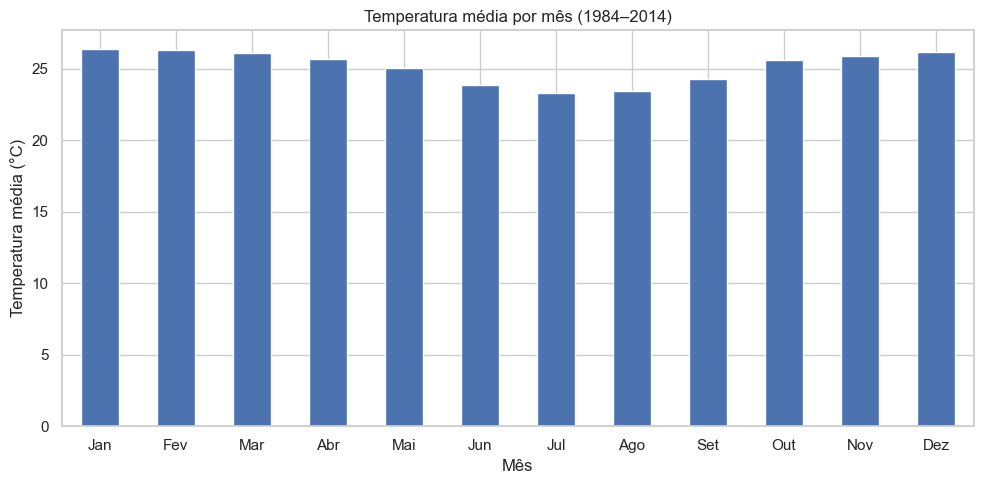

In [34]:
meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

ax = dados_mensais["C° - Temperatura Média"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Temperatura média por mês (1984–2014)",
)

ax.set_xticklabels(meses, rotation=0)
plt.xlabel("Mês")
plt.ylabel("Temperatura média (°C)")
plt.tight_layout()
plt.show()

O gráfico de temperatura média mensal mostra que:

- as temperaturas são mais altas no começo e no final do ano;
- ocorre redução no meio do ano;
- os menores valores aparecem por volta de junho e julho;
- há retomada da elevação térmica no segundo semestre.

### O que isso indica
Esses resultados revelam a presença de **sazonalidade térmica**. A temperatura média segue um ciclo anual relativamente bem definido, embora a variação entre os meses não seja muito intensa.

### Interpretação climática
A região mantém temperaturas elevadas ao longo de praticamente todo o ano, porém apresenta uma diminuição no meio do período anual. Esse comportamento pode estar relacionado à sazonalidade da radiação solar, da nebulosidade e da dinâmica atmosférica regional.


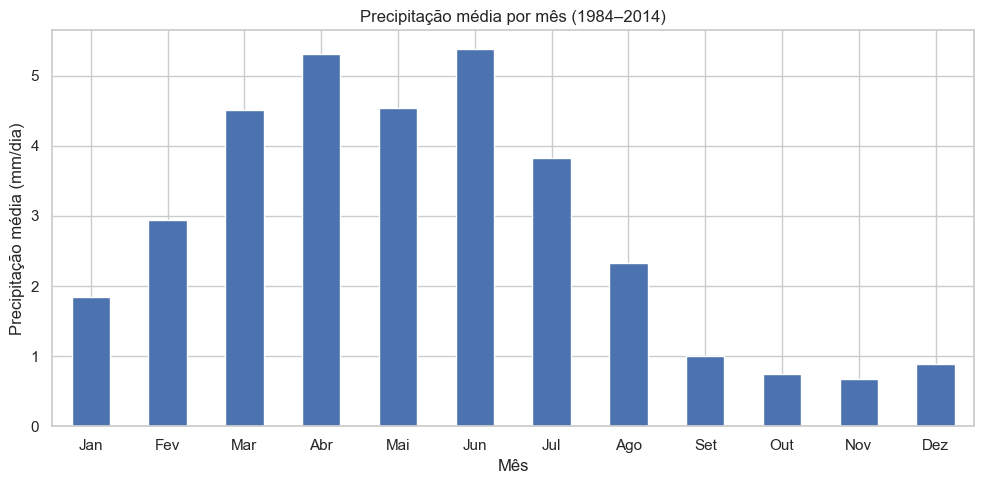

In [35]:
meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

ax = dados_mensais["mm/dia - Precipitação"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Precipitação média por mês (1984–2014)",
)

ax.set_xticklabels(meses, rotation=0)
plt.xlabel("Mês")
plt.ylabel("Precipitação média (mm/dia)")
plt.tight_layout()
plt.show()

### 3.3 Precipitação média por mês
O gráfico de precipitação média mensal evidencia que:

- a chuva aumenta entre março e junho;
- o pico ocorre no **mês 6**;
- há queda acentuada a partir de setembro;
- os menores valores se concentram entre outubro e dezembro.

Além disso, o resultado numérico confirmou:

- **mês com maior precipitação:** 6;
- **valor médio:** ≈ **5,38 mm/dia**.

### O que isso indica

No contexto do Semiárido Paraibano, esse comportamento sugere que:

- o período mais chuvoso está concentrado no primeiro semestre, com ápice em junho;
- o período mais seco ocorre no final do ano.

Esse padrão é coerente com a dinâmica climática típica da região.

In [36]:
serie_radiacao = dados.set_index("Data")["W/m² - Radiação"]

In [37]:
#Decomposicao sazonal por radiação

decomposicao = seasonal_decompose(
    serie_radiacao,
    model="additive",
    period=365
    #periodo de 365 dias, ou seja, um ano, para capturar a sazonalidade anual
)

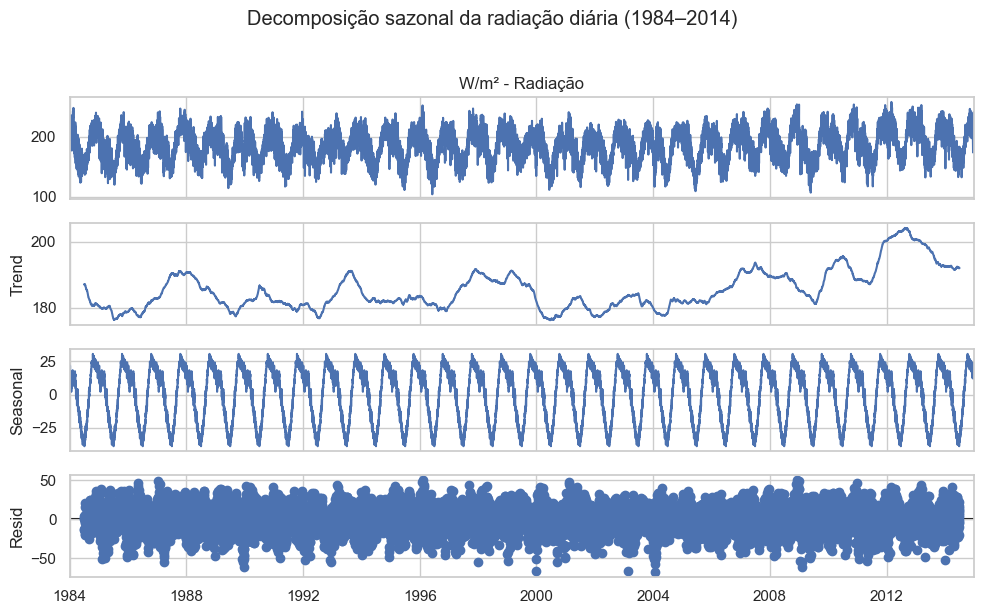

In [42]:
fig = decomposicao.plot()
fig.suptitle("Decomposição sazonal da radiação diária (1984–2014)", y=1.02)
plt.tight_layout()
plt.show()

### Como interpretar o gráfico de decomposição
O gráfico de decomposição separa a série temporal de radiação em quatro componentes, facilitando a interpretação do comportamento ao longo do tempo:

- **Série original (Observed)**: valores diários observados de radiação ao longo do período, com variações de curto prazo e repetição de padrões ao longo dos anos.
- **Tendência (Trend)**: comportamento de longo prazo (variações lentas), indicando mudanças graduais no nível médio da radiação ao longo da série histórica.
- **Sazonalidade (Seasonal)**: padrão periódico que se repete a cada ano (ciclo anual), evidenciando meses sistematicamente mais favoráveis (maior radiação) e menos favoráveis (menor radiação).
- **Resíduo (Resid)**: parte “irregular” não explicada por tendência e sazonalidade, associada à variabilidade diária e a eventos pontuais (ex.: nebulosidade atípica, frentes, etc.).

Em termos visuais, quando a componente **Seasonal** aparece com formato repetitivo e estável ao longo de toda a série, isso indica **sazonalidade anual forte e consistente** na radiação.

## 4. Decomposição sazonal da radiação

A decomposição sazonal foi aplicada à série temporal diária de radiação utilizando um modelo aditivo com período de 365 dias.

### Por que a abordagem está certa?

Foram utilizados:

- dados em frequência diária;
- periodicidade anual (`period = 365`);
- modelo aditivo.

### O que isso significa

Esse procedimento assume que a série de radiação pode ser representada como:

**Série original = Tendência + Sazonalidade + Resíduo**

#### Série original
Mostra as oscilações diárias da radiação ao longo do tempo, com repetição de padrões anuais.

#### Tendência
Mostra o comportamento de longo prazo da radiação, evidenciando oscilações gerais ao longo dos anos.

#### Componente sazonal
Mostra um padrão periódico bem definido, confirmando a repetição anual do comportamento da radiação.

#### Resíduo
Representa a parte aleatória da série, isto é, a variabilidade não explicada pela tendência nem pela sazonalidade.

In [39]:
mes_maior_radiacao = dados_mensais["W/m² - Radiação"].idxmax()
valor_maior_radiacao = dados_mensais["W/m² - Radiação"].max()

print("Mês com maior radiação:", mes_maior_radiacao)
print("Valor médio:", valor_maior_radiacao)

Mês com maior radiação: 10
Valor médio: 210.89665632674297


In [40]:
mes_menor_radiacao = dados_mensais["W/m² - Radiação"].idxmin()
valor_menor_radiacao = dados_mensais["W/m² - Radiação"].min()

print("Mês com menor radiação:", mes_menor_radiacao)
print("Valor médio:", valor_menor_radiacao)

Mês com menor radiação: 6
Valor médio: 150.98697638387097


In [41]:
mes_maior_chuva = dados_mensais["mm/dia - Precipitação"].idxmax()
valor_maior_chuva = dados_mensais["mm/dia - Precipitação"].max()

print("Mês com maior precipitação:", mes_maior_chuva)
print("Valor médio:", valor_maior_chuva)

Mês com maior precipitação: 6
Valor médio: 5.378998955323856


## 5. O que isso indica sobre a sazonalidade climática

De forma conjunta, os resultados mostram que as variáveis climáticas apresentam comportamento sazonal bem definido ao longo do ano.

### Radiação
- maior no segundo semestre;
- pico em outubro;
- mínimo em junho;
- forte sazonalidade anual;
- relação direta com o potencial fotovoltaico.

### Temperatura
- ciclo anual moderado;
- menores valores no meio do ano;
- maiores valores no início e no final do ano.

### Precipitação
- período chuvoso concentrado no primeiro semestre;
- valor máximo em junho;
- período seco mais intenso no final do ano.

Considerando o objetivo proposto para a análise de sazonalidade — identificar meses com maior radiação, menor potencial fotovoltaico e caracterizar o comportamento mensal das variáveis climáticas — os resultados mostram que:

- **maior radiação:** outubro (mês 10; média ≈ 210,90 W/m²);
- **menor radiação / menor potencial fotovoltaico:** junho (mês 6; média ≈ 150,99 W/m²);
- **maior precipitação:** junho (mês 6; média ≈ 5,38 na unidade original da planilha);
- **menores temperaturas:** meio do ano;
- **maiores temperaturas:** início e final do ano.

Em síntese, **junho** reúne simultaneamente baixa disponibilidade média de radiação e maior precipitação média, caracterizando o período menos favorável ao potencial fotovoltaico. Por outro lado, **outubro** representa o pico de radiação média e tende a ser o período mais favorável. A decomposição sazonal reforça a presença de um ciclo anual consistente na radiação ao longo da série histórica.